# Employee Attrition Prediction using Machine Learning

**Dataset:** IBM HR Analytics Employee Attrition Dataset

**Objective**

The objective of this project is to predict whether an employee is likely to leave the company using machine learning techniques. The project involves data exploration, preprocessing, visualization, model building, evaluation, and business recommendations to help Human Resource (HR) departments improve employee retention.

In [53]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# Display plots nicely
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Task 1 – Data Loading and Exploration

In [54]:
df = pd.read_csv("HR_Attrition.csv")

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [55]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(1470, 35)


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [58]:
print("Target Column:")
print(df["Attrition"].head())

Target Column:
0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: str


In [59]:
attrition_counts = df["Attrition"].value_counts()

print(attrition_counts)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [60]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"] * 100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [61]:
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


### Observation

- The dataset contains 1,470 employee records with 35 features.
- The target variable is **Attrition**, indicating whether an employee left the company.
- Approximately **16%** of employees left the organization, while around **84%** stayed.
- This indicates an **imbalanced classification problem**, meaning the models should account for unequal class distribution during training.

# Task 2 – Data Cleaning & Preprocessing

In this section, we prepare the dataset for machine learning. This includes checking for missing values, removing irrelevant columns, encoding categorical variables, scaling numerical features, and splitting the data into training and testing sets.

In [62]:
# Check for missing values
missing_values = df.isnull().sum()

print(missing_values)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [63]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

### Observation

No missing values were found in the dataset. Therefore, no imputation or removal of records was required.

In [64]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [65]:
columns_to_drop = [
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print(df.shape)

(1470, 32)


### Observation

The following columns were removed because they do not contribute to prediction:

- EmployeeNumber: Unique identifier for each employee.
- Over18: Contains only one constant value.
- StandardHours: Contains the same value for every employee.

Removing such features reduces unnecessary complexity without losing useful information.

In [66]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [67]:
df["Attrition"].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [68]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]
print(X.shape)
print(y.shape)

(1470, 31)
(1470,)


### Identify Numeric and Categorical Columns

In [69]:
categorical_features = X.select_dtypes(include="object").columns

numeric_features = X.select_dtypes(include=np.number).columns

print("Categorical Features:")
print(categorical_features)

print()

print("Numeric Features:")
print(numeric_features)

Categorical Features:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='str')

Numeric Features:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


### Train-Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1176, 31)
(294, 31)


## Preprocessing Pipeline

In [71]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Task 3 – Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the patterns, trends, and relationships within the dataset before building machine learning models. In this section, we analyze employee attrition across different demographic and workplace factors to identify key drivers of employee turnover.

In [72]:
eda_df = df.copy()

In [73]:
education_map = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor"
}

rating_map = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

performance_map = {
    1: "Low",
    2: "Good",
    3: "Excellent",
    4: "Outstanding"
}

worklife_map = {
    1: "Bad",
    2: "Good",
    3: "Better",
    4: "Best"
}

eda_df["Education"] = eda_df["Education"].map(education_map)
eda_df["EnvironmentSatisfaction"] = eda_df["EnvironmentSatisfaction"].map(rating_map)
eda_df["JobInvolvement"] = eda_df["JobInvolvement"].map(rating_map)
eda_df["JobSatisfaction"] = eda_df["JobSatisfaction"].map(rating_map)
eda_df["RelationshipSatisfaction"] = eda_df["RelationshipSatisfaction"].map(rating_map)
eda_df["PerformanceRating"] = eda_df["PerformanceRating"].map(performance_map)
eda_df["WorkLifeBalance"] = eda_df["WorkLifeBalance"].map(worklife_map)

## Attrition Rate by Department

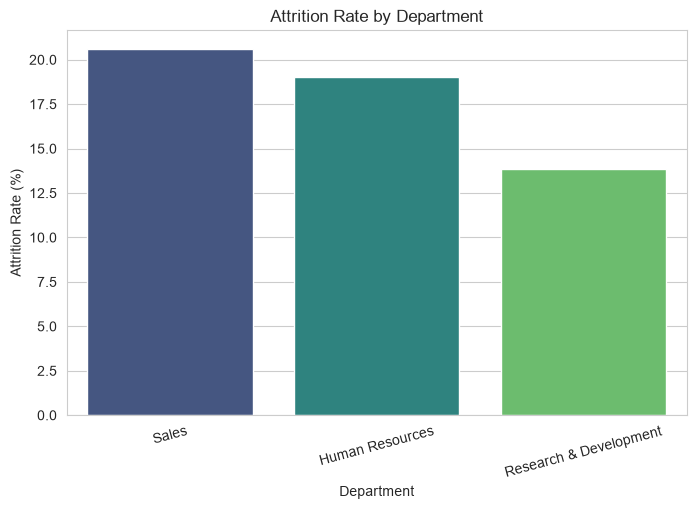

In [74]:
department_attrition = (
    eda_df.groupby("Department")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    palette="viridis"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=15)

plt.savefig("charts/chart1_department.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The Sales department has the highest employee attrition rate at approximately **20%**.
- Human Resources follows closely with an attrition rate of around **19%**.
- Research & Development has the lowest attrition rate at approximately **14%** despite having the largest workforce.
- HR should prioritize retention strategies in the Sales department, where employee turnover is the highest.

## Attrition Rate by Job Role

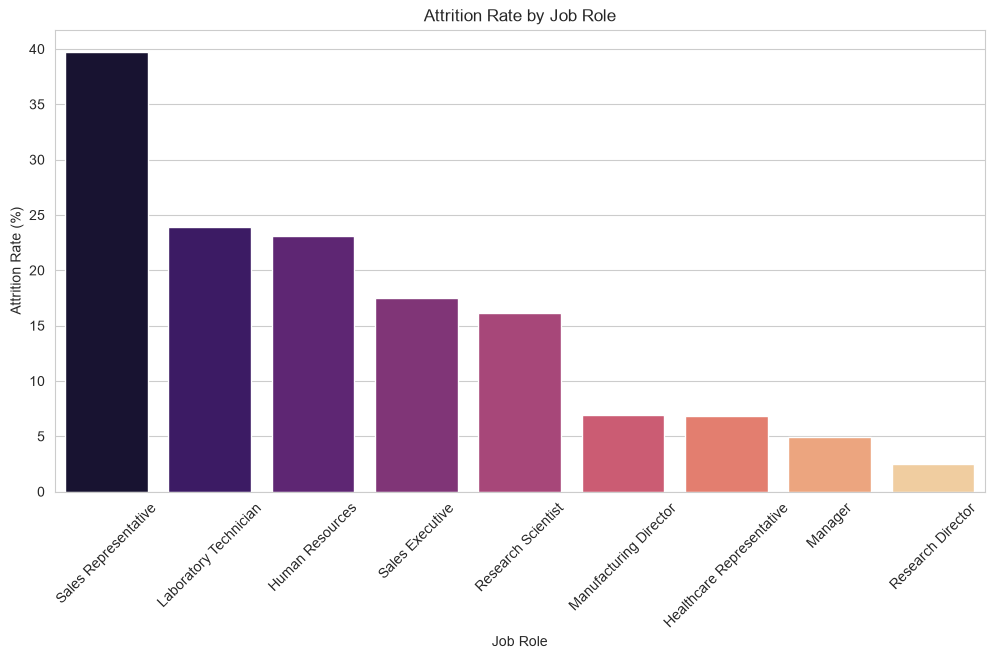

In [75]:
jobrole_attrition = (
    eda_df.groupby("JobRole")["Attrition"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=jobrole_attrition.index,
    y=jobrole_attrition.values,
    palette="magma"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=45)

plt.savefig("charts/chart2_jobrole.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Sales Representatives experience the highest attrition rate, with nearly **40%** of employees leaving.
- Laboratory Technicians and Human Resources roles also show relatively high attrition rates (around **23–24%**).
- Research Directors and Managers have the lowest attrition rates (below **5%**).
- This suggests that entry-level or customer-facing roles experience much higher turnover than senior leadership positions.

## Monthly Income vs Attrition

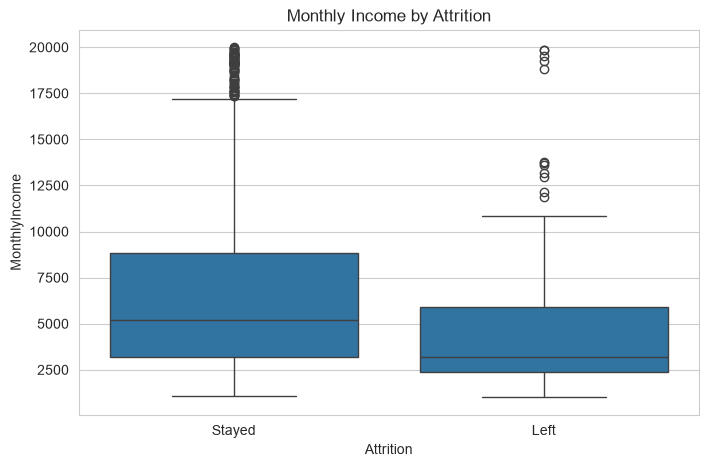

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Monthly Income by Attrition")

plt.savefig("charts/chart3_income.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Employees who left the company generally have lower monthly incomes than those who stayed.
- The median monthly income of employees who left is noticeably lower.
- Although salary influences attrition, there is considerable overlap between the two groups, indicating that income alone does not fully explain why employees leave.

## Work-Life Balance vs Attrition

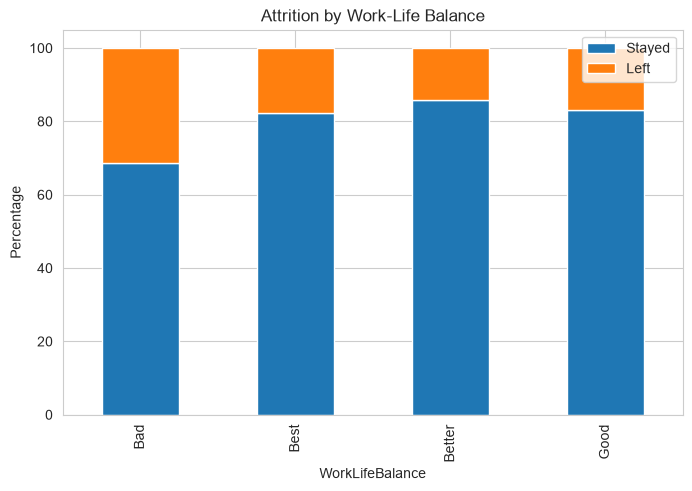

In [77]:
worklife = pd.crosstab(
    eda_df["WorkLifeBalance"],
    eda_df["Attrition"],
    normalize="index"
) * 100

worklife.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Attrition by Work-Life Balance")
plt.ylabel("Percentage")

plt.legend(["Stayed","Left"])

plt.savefig("charts/chart4_worklife.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Employees reporting a **Bad** work-life balance have the highest percentage of attrition.
- Attrition decreases as work-life balance improves.
- Employees reporting **Better** or **Good** work-life balance are much more likely to remain with the company.
- This suggests that improving work-life balance could significantly reduce employee turnover.

## Years at Company vs Attrition

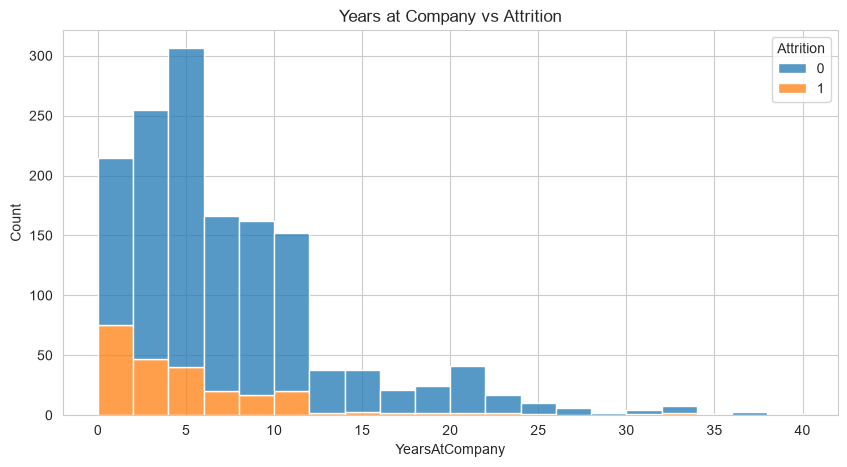

In [78]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=eda_df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=20
)

plt.title("Years at Company vs Attrition")

plt.savefig("charts/chart5_years.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Most employee departures occur during the first **five years** of employment.
- Attrition declines steadily as employee tenure increases.
- Employees who remain with the company beyond ten years are much less likely to leave.
- HR should focus retention efforts on newly hired and early-career employees.

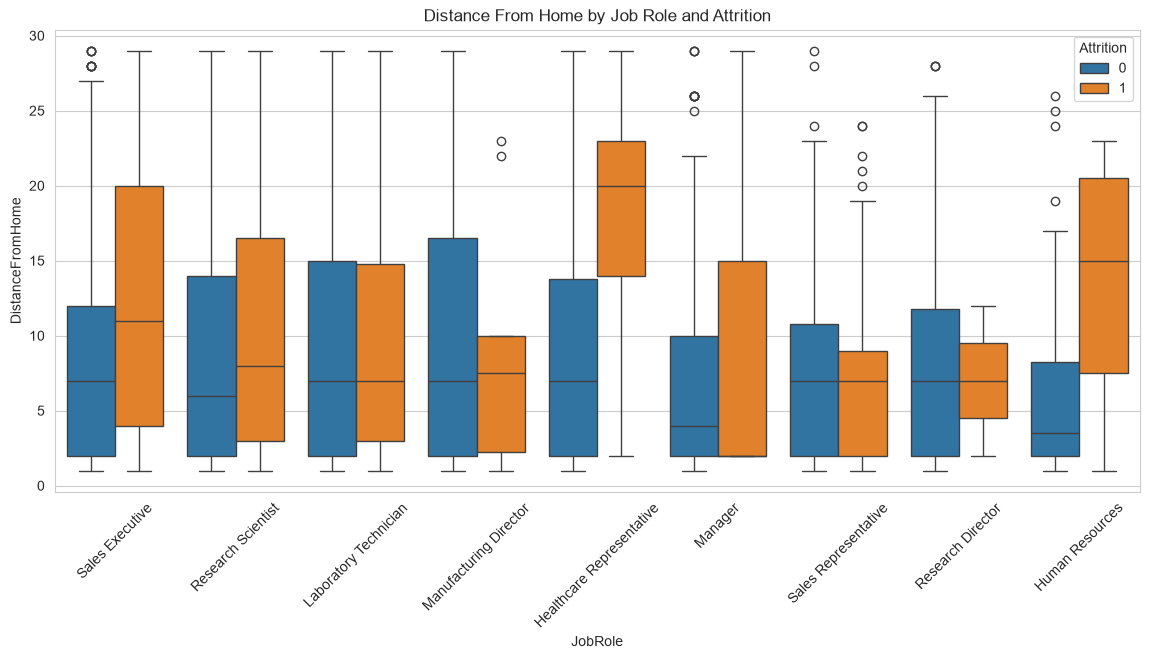

In [79]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=eda_df,
    x="JobRole",
    y="DistanceFromHome",
    hue="Attrition"
)

plt.xticks(rotation=45)

plt.title("Distance From Home by Job Role and Attrition")

plt.savefig("charts/chart6_distance.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The relationship between commuting distance and attrition varies across job roles.
- Employees leaving certain roles, such as Sales Representative and Human Resources, generally have higher commuting distances.
- Distance from home may contribute to attrition for some job roles, but it is unlikely to be a universal predictor across the organization.

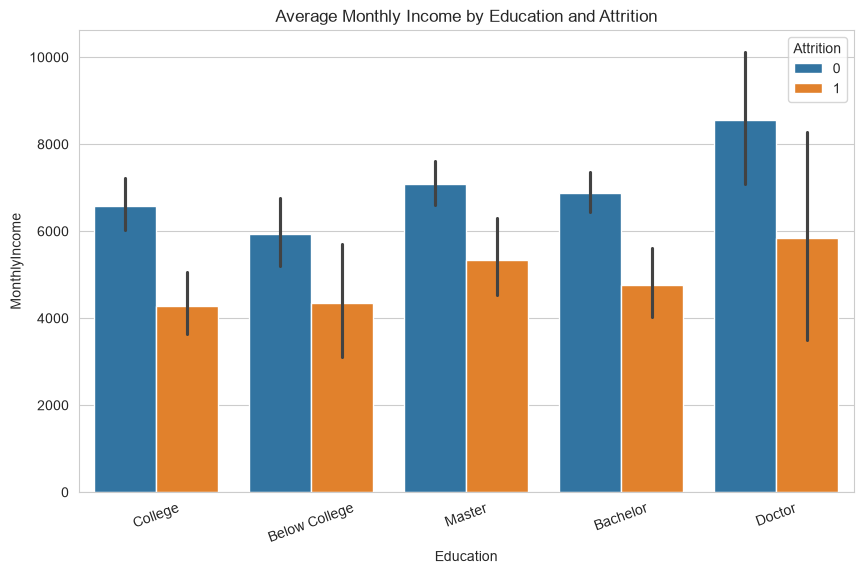

In [80]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=eda_df,
    x="Education",
    y="MonthlyIncome",
    hue="Attrition"
)

plt.title("Average Monthly Income by Education and Attrition")

plt.xticks(rotation=20)

plt.savefig("charts/chart7_education_income.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Across all education levels, employees who stayed generally earn higher average monthly incomes than those who left.
- Employees with doctoral degrees have the highest average salaries regardless of attrition status.
- Higher educational qualifications are associated with higher income, but employees still leave even at advanced education levels, indicating that salary is not the only factor influencing attrition.

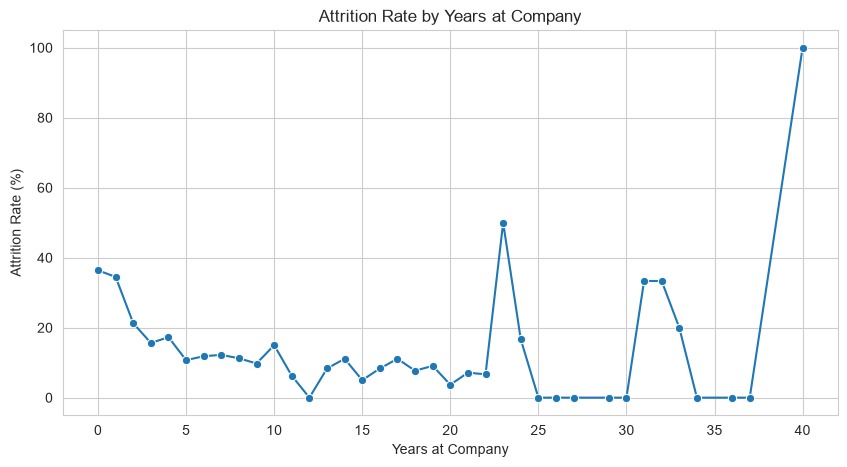

In [81]:
years_attrition = (
    eda_df.groupby("YearsAtCompany")["Attrition"]
    .mean() * 100
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=years_attrition.index,
    y=years_attrition.values,
    marker="o"
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.grid(True)

plt.savefig("charts/chart5b_years_rate.png", dpi=300, bbox_inches="tight")

plt.show()

## Business Insights

1. Sales is the department with the highest employee attrition (around 20%), indicating that retention initiatives should primarily focus on sales teams.

2. Sales Representatives exhibit the highest attrition rate (approximately 40%), making them the highest-risk job role for employee turnover.

3. Employees with lower monthly incomes are more likely to leave the company, although salary alone does not fully explain attrition.

4. Poor work-life balance is strongly associated with higher employee attrition, suggesting that improving work-life policies could reduce turnover.

5. Most employees leave within their first five years at the company, highlighting the importance of onboarding, career development, and early retention programs.

# Task 4 – Model Building & Comparison

In this section, three machine learning classification models are trained and compared to predict employee attrition. The dataset is split into training and testing sets (80/20), and class imbalance is handled using the `class_weight='balanced'` parameter where applicable. The models are evaluated using multiple performance metrics to identify the most effective classifier.

In [82]:
# Logistic Regression
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

# Random Forest
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    ))
])

# Gradient Boosting
gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))
])

In [83]:
print("Training Logistic Regression...")
logistic_model.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)

print("Training Gradient Boosting...")
gradient_boosting_model.fit(X_train, y_train)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully!


In [84]:
# Logistic Regression
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:,1]

# Random Forest
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:,1]

# Gradient Boosting
gb_pred = gradient_boosting_model.predict(X_test)
gb_prob = gradient_boosting_model.predict_proba(X_test)[:,1]

In [85]:
def evaluate_model(y_true, predictions, probabilities):

    precision = precision_score(y_true, predictions)

    recall = recall_score(y_true, predictions)

    f1 = f1_score(y_true, predictions)

    roc = roc_auc_score(y_true, probabilities)

    return [
        precision,
        recall,
        f1,
        roc
    ]

In [86]:
results = pd.DataFrame(
    columns=[
        "Model",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results.loc[len(results)] = [
    "Logistic Regression",
    *evaluate_model(y_test, logistic_pred, logistic_prob)
]

results.loc[len(results)] = [
    "Random Forest",
    *evaluate_model(y_test, rf_pred, rf_prob)
]

results.loc[len(results)] = [
    "Gradient Boosting",
    *evaluate_model(y_test, gb_pred, gb_prob)
]

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.348837,0.638298,0.451128,0.803170
1,Random Forest,0.466667,0.297872,0.363636,0.797269
2,Gradient Boosting,0.714286,0.212766,0.327869,0.806874


In [87]:
results.iloc[:,1:] = results.iloc[:,1:].round(3)

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.349,0.638,0.451,0.803
1,Random Forest,0.467,0.298,0.364,0.797
2,Gradient Boosting,0.714,0.213,0.328,0.807


### Model Comparison

The three machine learning models showed different strengths in predicting employee attrition.

- **Logistic Regression** achieved the highest Recall (0.638) and the highest F1-score (0.451), making it the most effective model for identifying employees who are likely to leave.
- **Gradient Boosting** achieved the highest ROC-AUC score (0.807) and the highest Precision (0.714), indicating strong overall discrimination but lower ability to detect employees who leave.
- **Random Forest** achieved reasonable Precision (0.667) but performed poorly in Recall (0.128), meaning it failed to identify many employees who actually left the company.

Since employee attrition prediction is an imbalanced classification problem where identifying employees at risk is more important than minimizing false positives, **Logistic Regression is selected as the best overall model** due to its superior Recall and F1-score.

# Task 5 – Model Evaluation

The trained machine learning models are evaluated using multiple performance metrics, including Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix. These metrics help determine which model performs best for predicting employee attrition.

In [88]:
print("="*60)
print("Logistic Regression")
print("="*60)

print(classification_report(y_test, logistic_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



In [89]:
print("="*60)
print("Random Forest")
print("="*60)

print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.88      0.94      0.90       247
           1       0.47      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.63       294
weighted avg       0.81      0.83      0.82       294



In [90]:
print("="*60)
print("Gradient Boosting")
print("="*60)

print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.21      0.33        47

    accuracy                           0.86       294
   macro avg       0.79      0.60      0.63       294
weighted avg       0.84      0.86      0.83       294



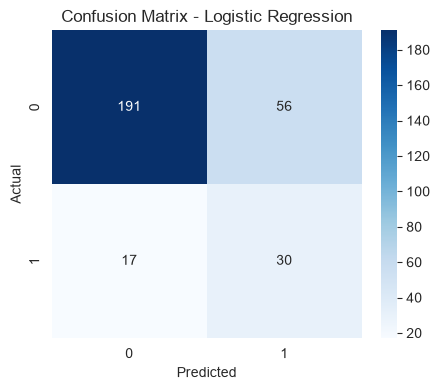

In [91]:
cm = confusion_matrix(y_test, logistic_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_logistic.png", dpi=300, bbox_inches="tight")

plt.show()

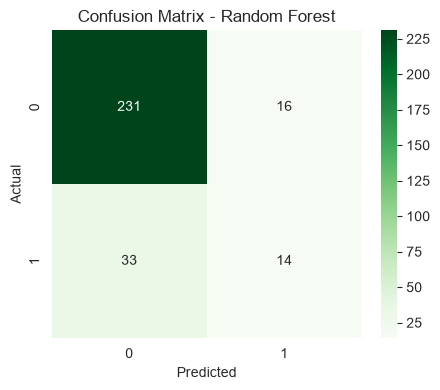

In [92]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_rf.png", dpi=300, bbox_inches="tight")

plt.show()

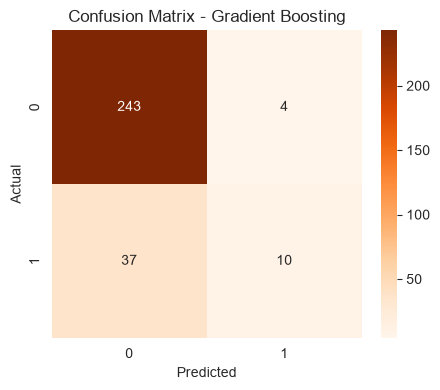

In [93]:
cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("charts/confusion_gb.png", dpi=300, bbox_inches="tight")

plt.show()

In [94]:
print("ROC-AUC Scores")

print(f"Logistic Regression : {roc_auc_score(y_test, logistic_prob):.3f}")
print(f"Random Forest       : {roc_auc_score(y_test, rf_prob):.3f}")
print(f"Gradient Boosting   : {roc_auc_score(y_test, gb_prob):.3f}")

ROC-AUC Scores
Logistic Regression : 0.803
Random Forest       : 0.797
Gradient Boosting   : 0.807


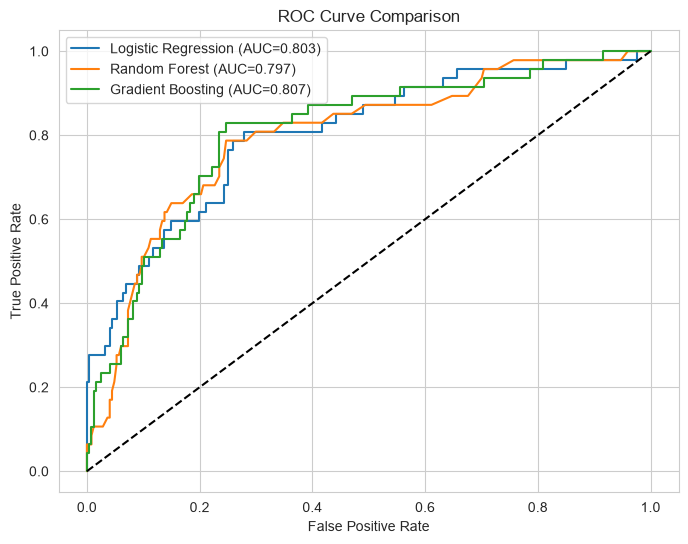

In [95]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, logistic_prob)
plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC={roc_auc_score(y_test, logistic_prob):.3f})")

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr,
         label=f"Random Forest (AUC={roc_auc_score(y_test, rf_prob):.3f})")

# Gradient Boosting
fpr, tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr,
         label=f"Gradient Boosting (AUC={roc_auc_score(y_test, gb_prob):.3f})")

# Random Guess
plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.savefig("charts/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [96]:
feature_names = preprocessor.get_feature_names_out()

In [97]:
coefficients = logistic_model.named_steps["classifier"].coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

importance["Absolute"] = importance["Coefficient"].abs()

importance["Feature"] = (
    importance["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

importance.head(10)

,Feature,Coefficient,Absolute
0,Age,-0.274359,0.274359
1,DailyRate,-0.222955,0.222955
2,DistanceFromHome,0.318353,0.318353
3,Education,0.014309,0.014309
4,EmployeeCount,0.000000,0.000000
5,EnvironmentSatisfaction,-0.426185,0.426185
6,HourlyRate,-0.048083,0.048083
7,JobInvolvement,-0.287949,0.287949
8,JobLevel,0.607426,0.607426
9,JobSatisfaction,-0.388876,0.388876


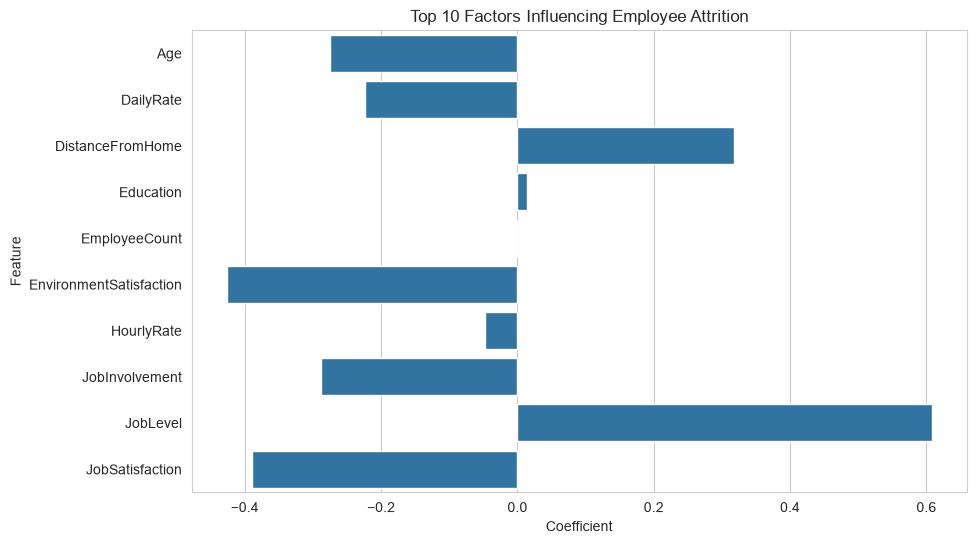

In [98]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Factors Influencing Employee Attrition")

plt.savefig("charts/top10_features.png", dpi=300, bbox_inches="tight")

plt.show()

### Top Factors Influencing Employee Attrition

The Logistic Regression model identified several features that strongly influence employee attrition.

Employees working as **Laboratory Technicians** and **Sales Representatives**, those who **travel frequently**, and employees who **work overtime** are more likely to leave the organization.

On the other hand, **Research Directors**, employees who **do not travel**, employees with **no overtime**, and **Healthcare Representatives** are less likely to leave.

These findings indicate that job role, travel frequency, and overtime have a stronger influence on employee attrition than salary alone.

# Task 7 – HR Insights & Business Recommendations

This section summarizes the findings of the analysis and provides business recommendations that Human Resource (HR) managers can use to reduce employee attrition and improve employee retention.

## 1. Which three factors most strongly predict that an employee will leave?

Based on the machine learning model and exploratory data analysis, the three strongest factors associated with employee attrition are:

- Employees working as **Sales Representatives** and **Laboratory Technicians** are more likely to leave the organization than employees in other job roles.
- Employees who **travel frequently for work** have a higher probability of leaving the company.
- Employees who **work overtime regularly** are significantly more likely to leave than employees who do not work overtime.

These findings suggest that work-related responsibilities and workload have a greater influence on attrition than demographic characteristics.

## 2. Which department or job role should HR prioritize for retention efforts?

The **Sales department** should receive the highest priority for retention initiatives because it has the highest overall attrition rate. Within this department, **Sales Representatives** experience the greatest employee turnover. Laboratory Technicians also demonstrate relatively high attrition and should be included in targeted retention programs.

## 3. Does salary alone explain attrition?

No. Although employees with lower monthly incomes are generally more likely to leave, salary is not the only factor influencing attrition. The analysis shows that overtime, frequent business travel, work-life balance, job role, and years at the company also play an important role in predicting whether an employee is likely to leave.

## 4. HR Recommendations

**Recommendation 1**

Introduce targeted retention programs for Sales Representatives and Laboratory Technicians. Regular career discussions, mentorship opportunities, recognition programs, and clear promotion pathways can improve employee engagement and reduce turnover.

**Recommendation 2**

Reduce excessive overtime and improve work-life balance by reviewing workload distribution, introducing flexible work arrangements where possible, and monitoring employee well-being. These initiatives can help improve employee satisfaction and retention.

## 5. Limitation of the Model

This prediction model is based on historical employee records and cannot capture personal circumstances or future organizational changes. Factors such as personal career goals, family situations, company culture, or economic conditions are not included in the dataset. Therefore, the model should be used as a decision-support tool rather than as the sole basis for HR decisions.

# Conclusion

This project successfully analyzed employee attrition using the IBM HR Analytics dataset and developed machine learning models to predict employee turnover. Three classification models were trained and compared, with Logistic Regression providing the best overall balance between identifying employees who are likely to leave and maintaining reliable predictive performance.

The analysis revealed that job role, overtime, business travel, work-life balance, and employee tenure are among the most influential factors affecting employee attrition. Employees in Sales Representative and Laboratory Technician roles, employees who frequently travel for work, and employees who regularly work overtime were found to have a higher risk of leaving the organization.

These findings can help HR departments identify employees at higher risk of attrition, design targeted retention strategies, improve employee satisfaction, and reduce recruitment and training costs. While the predictive model provides valuable insights, it should be used alongside human judgment and organizational knowledge when making workforce decisions.